In [17]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
import json
import operator
import os

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

In [18]:
load_dotenv()

True

In [19]:
llm = ChatOpenAI(model = "gpt-4o-mini")

In [20]:
# for structure output 
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(description='Sentiment of the review')

In [21]:
sentiment_model = llm.with_structured_output(SentimentSchema)

In [22]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [23]:
diagnosis_model = llm.with_structured_output(DiagnosisSchema)

In [24]:
# prompt = "what is the sentiment of the review - the team is not good"
# sentiment_model.invoke(prompt).sentiment

In [25]:
# define the state:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative']
    diagnosis: dict
    response : str

In [26]:
def find_sentiment(state: ReviewState):

    prompt = f"For the Following review find out the sentiment \n {state['review']}"

    sentiment = sentiment_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}



In [34]:
def check_sentiment(state: ReviewState) -> Literal['positive_response', 'run_diagnosis']:

    if state['sentiment'] == 'positive':
        return 'positive_response'

    else:
        return 'negative_response'

In [35]:
def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = llm.invoke(prompt).content

    return {'response': response}

In [36]:
def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = llm.invoke(prompt).content

    return {'response': response}

In [37]:
def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = diagnosis_model.invoke(prompt)

    return {'diagnosis': response.model_dump()}

In [38]:
# define the stateGraph

graph = StateGraph(ReviewState)

# add node
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('negative_response', negative_response)
graph.add_node('run_diagnosis', run_diagnosis)


#add edge
graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

# compile the graph

workflow = graph.compile()



ValueError: At 'find_sentiment' node, 'check_sentiment' branch found unknown target 'negative_respons'

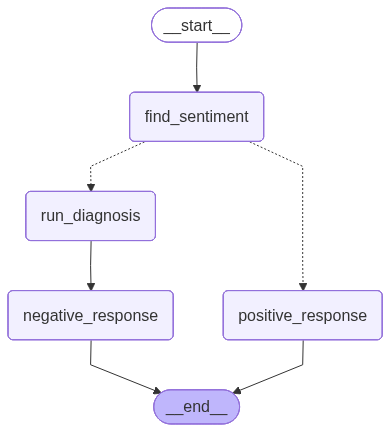

In [32]:
from IPython.display import Image

Image(
    workflow.get_graph().draw_mermaid_png()
)

In [33]:
initial_state = {
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

final_state = workflow.invoke(initial_state)
final_state

KeyError: 'negative_response'